In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

In [2]:
task_1_result_path = "../artifacts/pos_tagging_results.csv"
task_2_result_path = "../artifacts/ner_results.csv"

task_1_name = "POS Tagging"
task_2_name = "NER"

In [3]:
task_1_results = pd.read_csv(task_1_result_path)
task_2_results = pd.read_csv(task_2_result_path)

cross_task_results = pd.concat([task_1_results, task_2_results], ignore_index=True)

In [4]:
def get_architecture(name):
    name = name.lower()
    if "hmm" in name:
        return "HMM"
    if "crf" in name:
        return "CRF"
    if "bilstm" in name:
        return "BiLSTM-CRF"
    if "transformer" in name:
        return "RoBERTa"
    return "Other"


def get_optimization(name):
    name = name.lower()
    if "smart-batching" in name:
        return "Smart Batching"
    elif "dynamic-quantized" in name:
        return "Dynamic Quantization"
    elif "weight-only-quantized" in name:
        return "Weight-Only Quantization"
    elif "onnx" in name:
        return "ONNX"
    elif "batch-128" in name:
        return "Standard Batching"
    else:
        return "No Optimization"

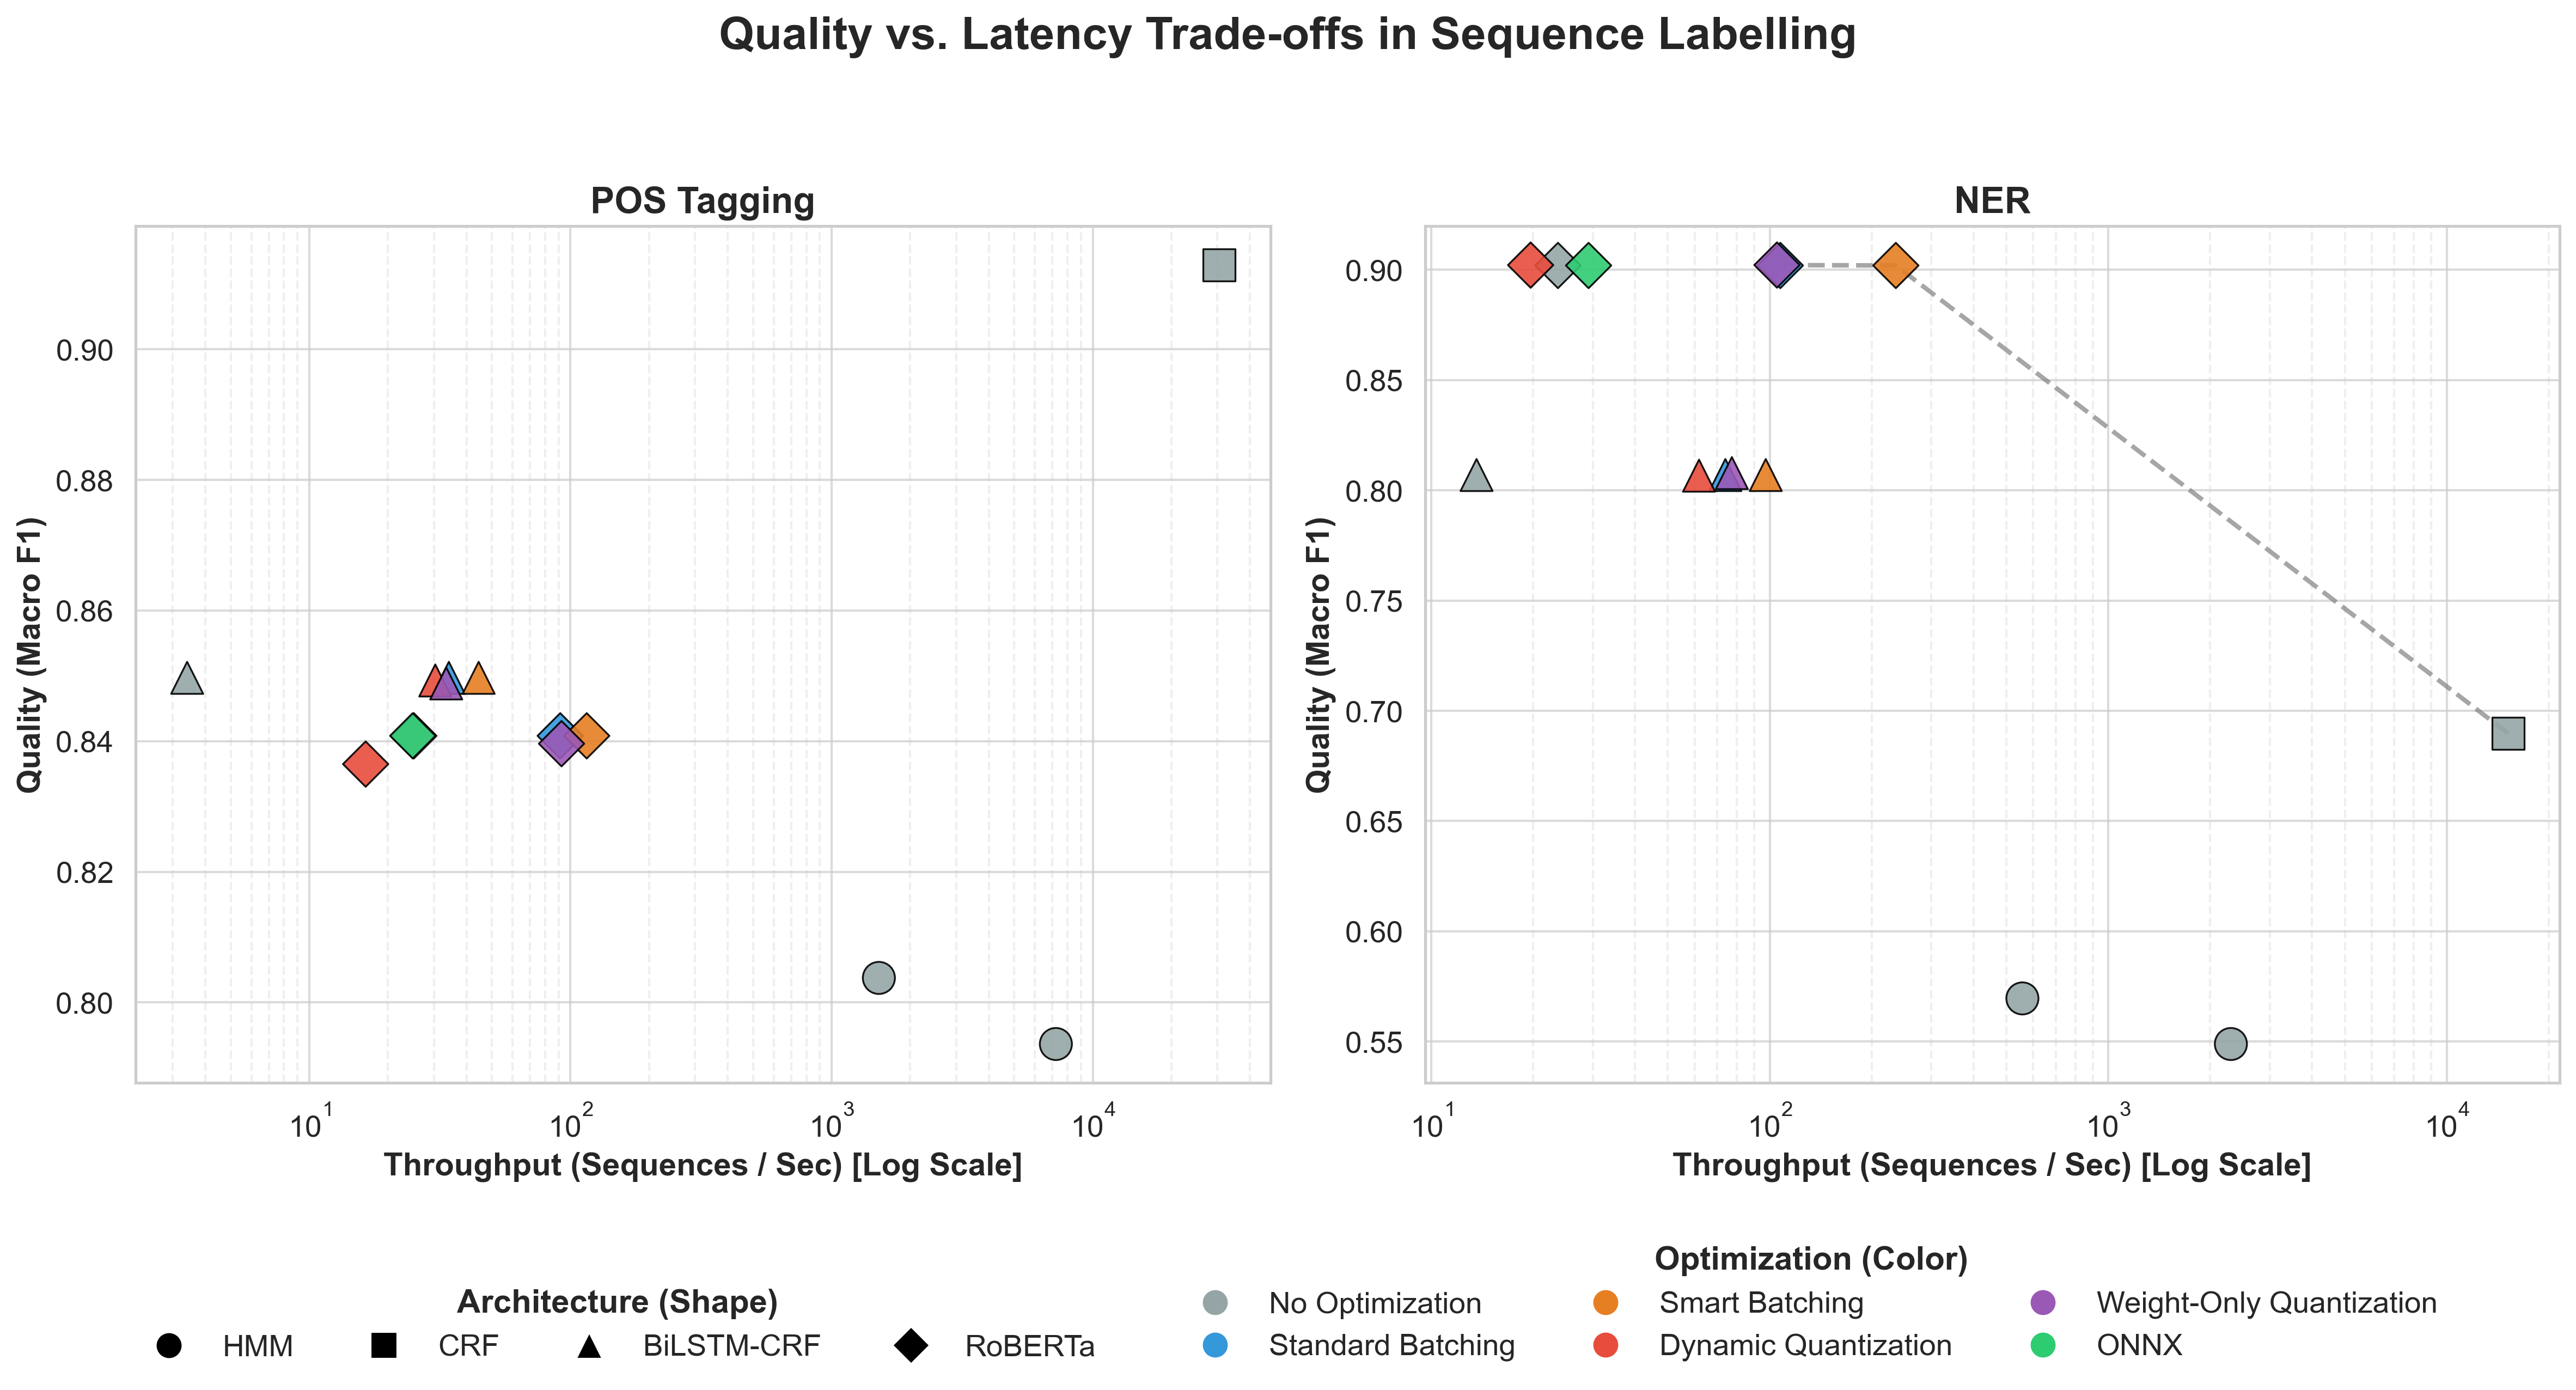

In [5]:
def get_pareto_frontier(df, x_col="throughput_seq_per_sec", y_col="macro_f1"):
    # Sort by throughput descending (fastest to slowest)
    sorted_df = df.sort_values(by=x_col, ascending=False).reset_index(drop=True)

    pareto_x = []
    pareto_y = []
    max_y_so_far = -np.inf

    # A point is on the Pareto frontier if it has a strictly higher F1 than any faster model
    for _, row in sorted_df.iterrows():
        if row[y_col] > max_y_so_far:
            pareto_x.append(row[x_col])
            pareto_y.append(row[y_col])
            max_y_so_far = row[y_col]

    return pareto_x, pareto_y


sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["font.family"] = "sans-serif"

# Define Palettes and Markers (Should be synchronized with helper functions above)
color_palette = {
    "No Optimization": "#95a5a6",
    "Standard Batching": "#3498db",
    "Smart Batching": "#e67e22",
    "Dynamic Quantization": "#e74c3c",
    "Weight-Only Quantization": "#9b59b6",
    "ONNX": "#2ecc71",
}

marker_palette = {
    "HMM": "o",
    "CRF": "s",
    "BiLSTM-CRF": "^",
    "RoBERTa": "D",
}

for df in [task_1_results, task_2_results]:
    df["Architecture"] = df["name"].apply(get_architecture)
    df["Optimization"] = df["name"].apply(get_optimization)

metric_col = "macro_f1"

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=300)
fig.suptitle(
    "Quality vs. Latency Trade-offs in Sequence Labelling",
    fontsize=20,
    weight="bold",
    y=1.05,
)

datasets = [(task_1_results, "POS Tagging", axes[0]), (task_2_results, "NER", axes[1])]

for df, title, ax in datasets:
    # Calculate Pareto
    p_x, p_y = get_pareto_frontier(df, x_col="throughput_seq_per_sec", y_col=metric_col)

    # Plot Pareto Line
    ax.plot(
        p_x,
        p_y,
        linestyle="--",
        color="gray",
        alpha=0.7,
        linewidth=2,
        zorder=1,
        label="Pareto Frontier",
    )

    # Plot Scatter Points
    sns.scatterplot(
        data=df,
        x="throughput_seq_per_sec",
        y=metric_col,
        hue="Optimization",
        style="Architecture",
        palette=color_palette,
        markers=marker_palette,
        s=200,  # Large markers for poster visibility
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9,
        ax=ax,
        zorder=2,
    )

    # Formatting the axes
    ax.set_title(title, fontsize=16, weight="bold")
    ax.set_xscale("log")
    ax.set_xlabel(
        "Throughput (Sequences / Sec) [Log Scale]", fontsize=14, weight="bold"
    )
    ax.set_ylabel(
        f"Quality ({metric_col.replace('_', ' ').title()})",
        fontsize=14,
        weight="bold",
    )

    # Add minor grid lines for the log scale
    ax.grid(True, which="minor", ls="--", alpha=0.3)
    ax.grid(True, which="major", ls="-", alpha=0.7)

    # Remove individual legends (we will make one global legend)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Architecture Legend
arch_handles = [
    Line2D(
        [0],
        [0],
        marker=marker_palette[arch],
        color="w",
        markerfacecolor="black",
        markersize=12,
        label=arch,
    )
    for arch in marker_palette.keys()
]

# Optimization Legend - reordered to match the image
opt_order = [
    "No Optimization",
    "Standard Batching",
    "Smart Batching",
    "Dynamic Quantization",
    "Weight-Only Quantization",
    "ONNX",
]
opt_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=color_palette[opt],
        markersize=12,
        label=opt,
    )
    for opt in opt_order
]

# Pareto Line Legend
pareto_handle = [
    Line2D([0], [0], color="gray", linestyle="--", linewidth=2, label="Pareto Frontier")
]

# Add the legends to the figure
leg1 = fig.legend(
    handles=arch_handles,
    title="Architecture (Shape)",
    loc="lower left",
    bbox_to_anchor=(0.05, -0.15),
    ncol=4,
    frameon=False,
    title_fontproperties={"weight": "bold"},
)
leg2 = fig.legend(
    handles=opt_handles,
    title="Optimization (Color)",
    loc="lower right",
    bbox_to_anchor=(0.95, -0.15),
    ncol=3,
    frameon=False,
    title_fontproperties={"weight": "bold"},
)

plt.tight_layout()
plt.savefig("pareto_frontier_poster.png", dpi=300, bbox_inches="tight")
plt.show()

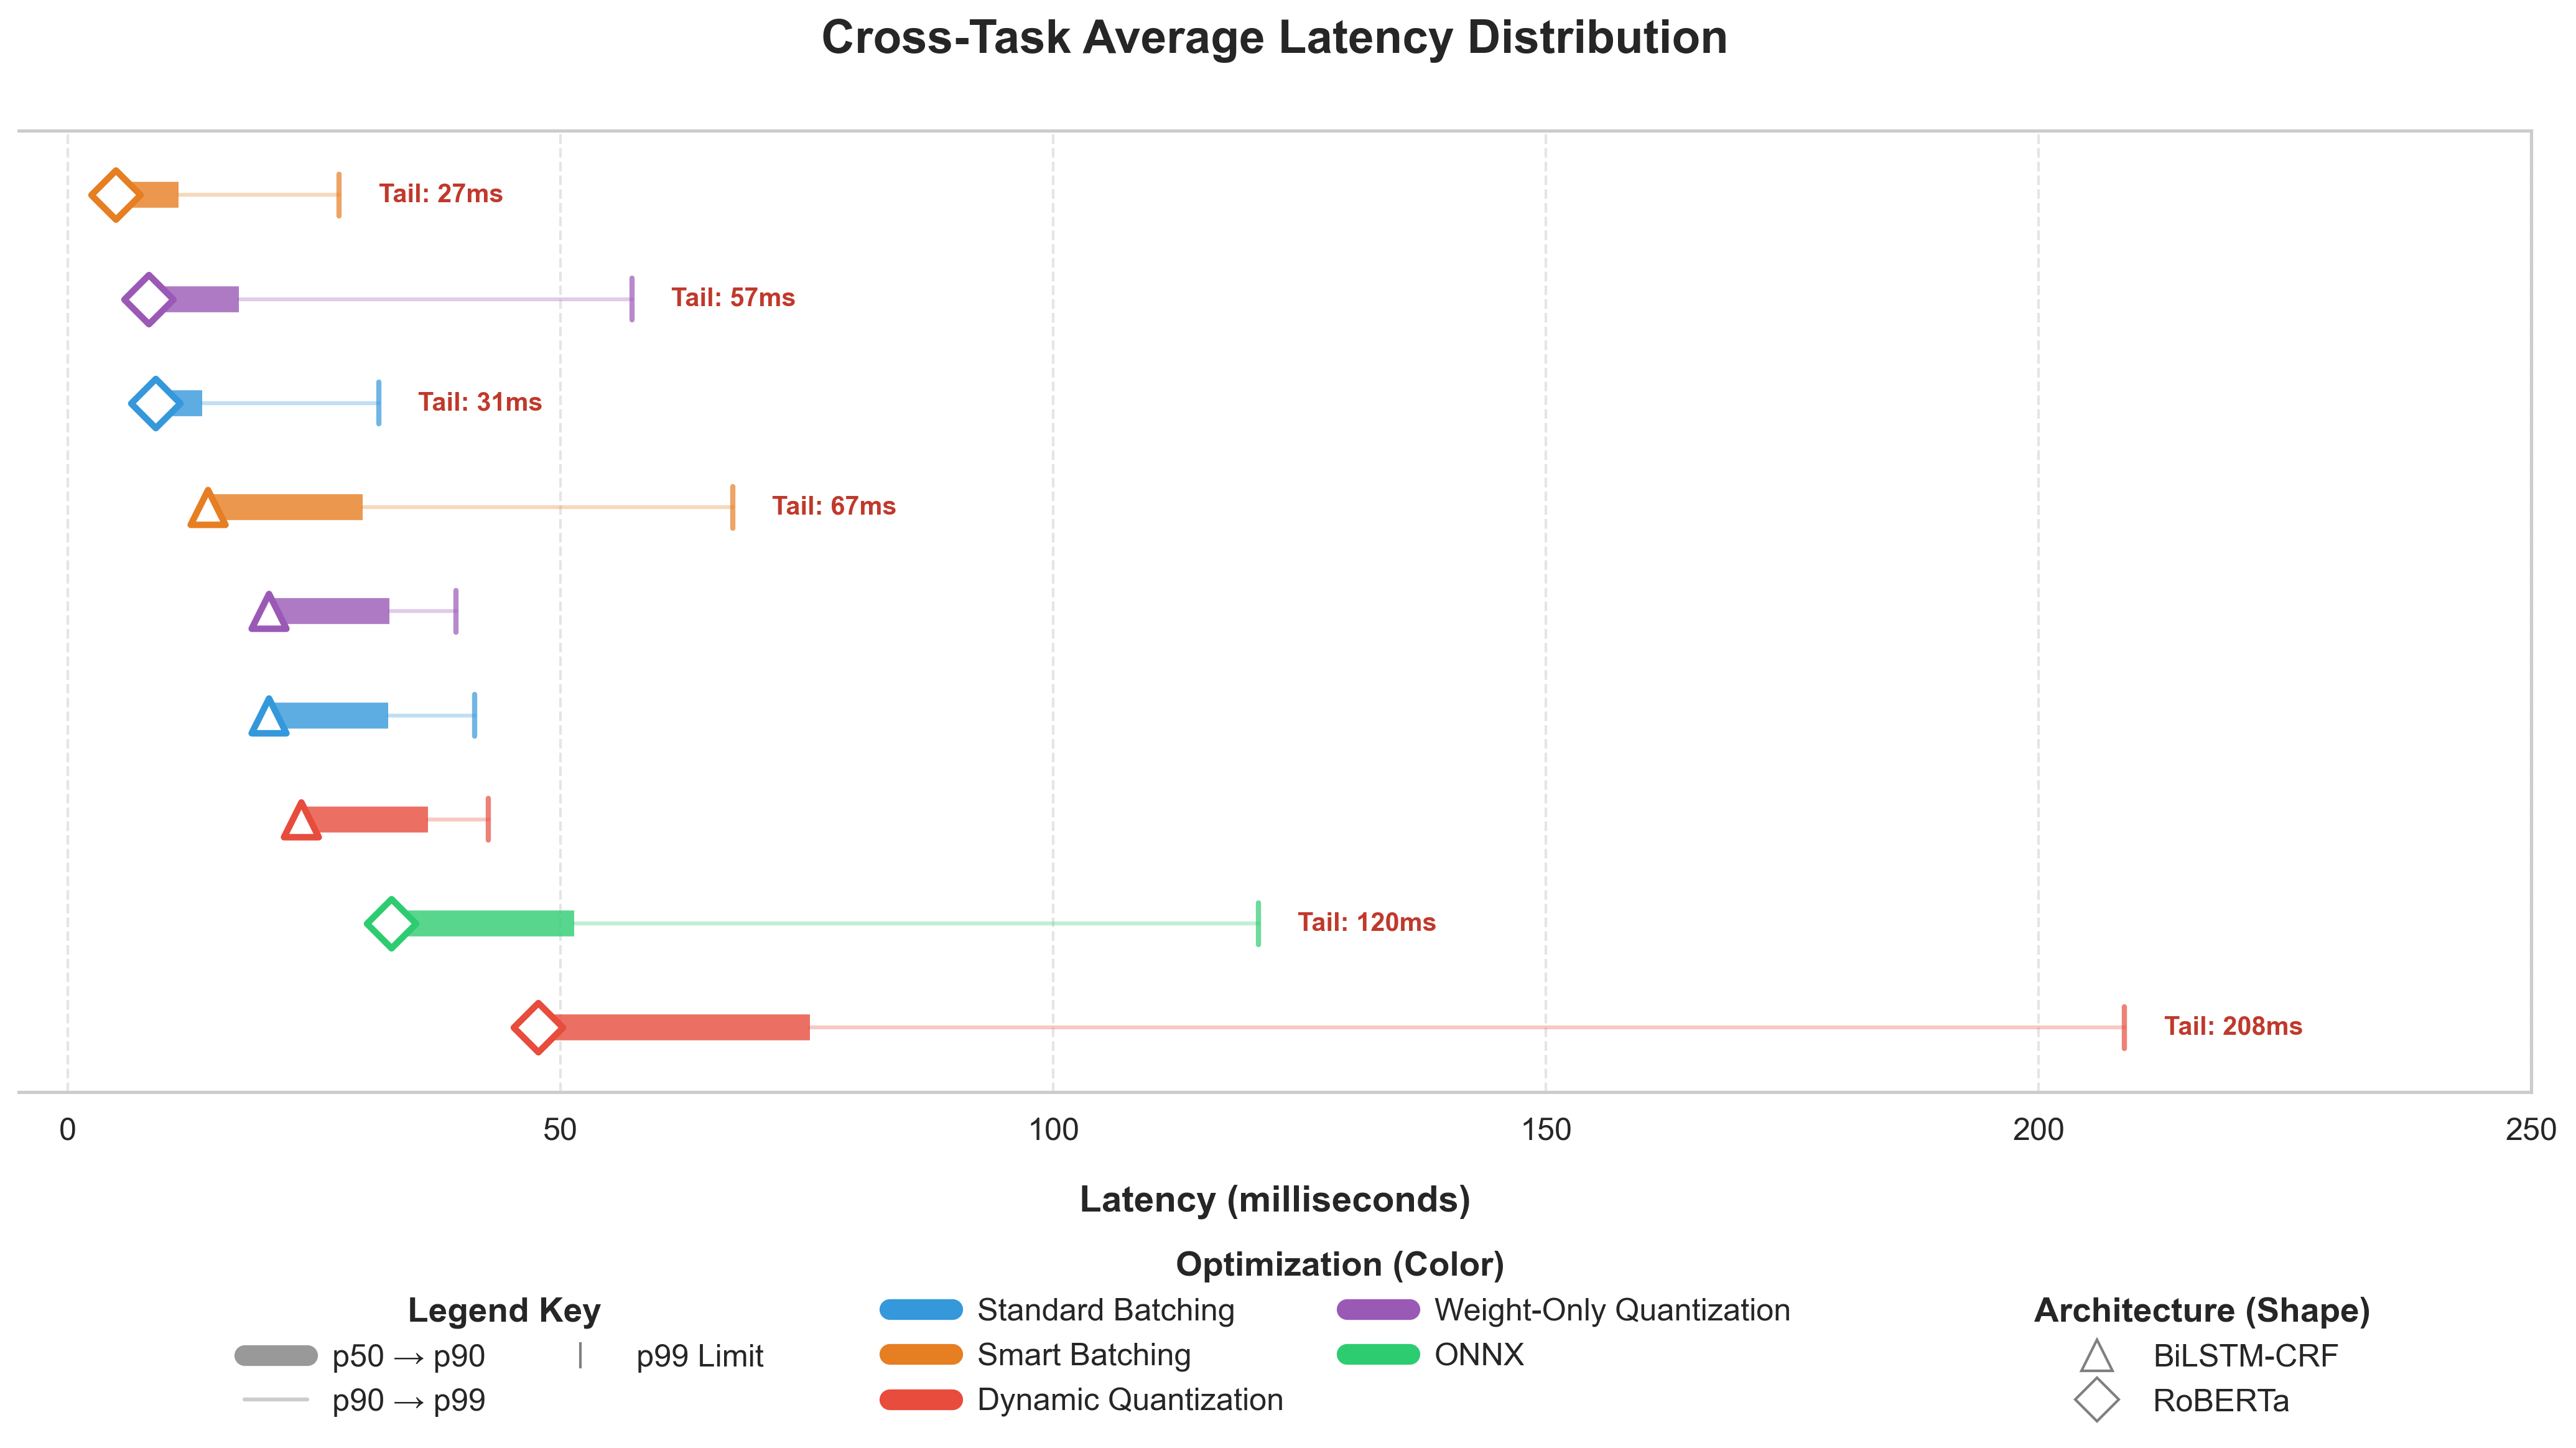

In [6]:
# Add metadata columns before grouping
cross_task_results["Architecture"] = cross_task_results["name"].apply(get_architecture)
cross_task_results["Optimization"] = cross_task_results["name"].apply(get_optimization)

df_plot = (
    cross_task_results.groupby(["name", "Architecture", "Optimization"])
    .mean(numeric_only=True)
    .reset_index()
)

# Filter for the specific models you want to show
target_models = [
    "bilstm-batch-128",
    "bilstm-batch-128-smart-batching",
    "dynamic-quantized-bilstm-batch-128",
    "weight-only-quantized-bilstm-batch-128",
    "transformer-batch-128",
    "transformer-batch-128-smart-batching",
    "dynamic-quantized-transformer-batch-128",
    "weight-only-quantized-transformer-batch-128",
    "onnx-transformer-batch-128",
]
df_plot = df_plot[df_plot["name"].isin(target_models)].copy()

# Sort by median latency (fastest at top)
df_plot = df_plot.sort_values("p50_latency_ms", ascending=False).reset_index(drop=True)

# Plotting
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(14, 7), dpi=300)

color_palette = {
    "Standard Batching": "#3498db",
    "Smart Batching": "#e67e22",
    "Dynamic Quantization": "#e74c3c",
    "Weight-Only Quantization": "#9b59b6",
    "ONNX": "#2ecc71",
}
marker_palette = {"BiLSTM-CRF": "^", "RoBERTa": "D"}

for i, row in df_plot.iterrows():
    opt_color = color_palette[row["Optimization"]]
    arch_marker = marker_palette[row["Architecture"]]

    # Range Lines
    ax.plot(
        [row["p90_latency_ms"], row["p99_latency_ms"]],
        [i, i],
        color=opt_color,
        linewidth=1.5,
        alpha=0.3,
        zorder=1,
    )
    ax.plot(
        [row["p50_latency_ms"], row["p90_latency_ms"]],
        [i, i],
        color=opt_color,
        linewidth=10,
        solid_capstyle="butt",
        alpha=0.8,
        zorder=2,
    )

    # p99 Vertical Marker
    ax.plot(
        [row["p99_latency_ms"], row["p99_latency_ms"]],
        [i - 0.2, i + 0.2],
        color=opt_color,
        linewidth=2,
        alpha=0.7,
        zorder=2,
    )

    # Median Shape
    ax.scatter(
        row["p50_latency_ms"],
        i,
        marker=arch_marker,
        color="white",
        edgecolor=opt_color,
        s=180,
        linewidth=2.5,
        zorder=3,
    )

    # Label tail spikes
    if (row["p99_latency_ms"] / row["p50_latency_ms"]) > 3:
        ax.text(
            row["p99_latency_ms"] + 4,
            i,
            f"Tail: {int(row['p99_latency_ms'])}ms",
            va="center",
            color="#c0392b",
            fontsize=10,
            fontweight="bold",
        )

# 3. Final Touches
ax.set_yticks([])
ax.set_xlabel("Latency (milliseconds)", fontsize=14, fontweight="bold", labelpad=15)
ax.set_title(
    "Cross-Task Average Latency Distribution",
    fontsize=18,
    fontweight="bold",
    pad=30,
)
ax.set_xlim(-5, 250)
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.spines["left"].set_visible(False)

# Legend Layout (Aligned vertically)
arch_handles = [
    Line2D(
        [0],
        [0],
        marker=marker_palette[k],
        color="w",
        markeredgecolor="gray",
        markerfacecolor="white",
        markersize=12,
        label=k,
    )
    for k in marker_palette.keys()
]
opt_handles = [
    Line2D([0], [0], color=color_palette[k], lw=8, label=k)
    for k in color_palette.keys()
]
comp_handles = [
    Line2D([0], [0], color="gray", lw=8, alpha=0.8, label="p50 → p90"),
    Line2D([0], [0], color="gray", lw=1.5, alpha=0.4, label="p90 → p99"),
    Line2D(
        [0],
        [0],
        color="gray",
        marker="|",
        linestyle="None",
        markersize=10,
        label="p99 Limit",
    ),
]

leg1 = fig.legend(
    handles=comp_handles,
    title="Legend Key",
    loc="lower center",
    bbox_to_anchor=(0.2, -0.12),
    ncol=2,
    frameon=False,
    title_fontproperties={"weight": "bold"},
)
leg2 = fig.legend(
    handles=opt_handles,
    title="Optimization (Color)",
    loc="lower center",
    bbox_to_anchor=(0.52, -0.12),
    ncol=2,
    frameon=False,
    title_fontproperties={"weight": "bold"},
)
leg3 = fig.legend(
    handles=arch_handles,
    title="Architecture (Shape)",
    loc="lower center",
    bbox_to_anchor=(0.85, -0.12),
    ncol=1,
    frameon=False,
    title_fontproperties={"weight": "bold"},
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

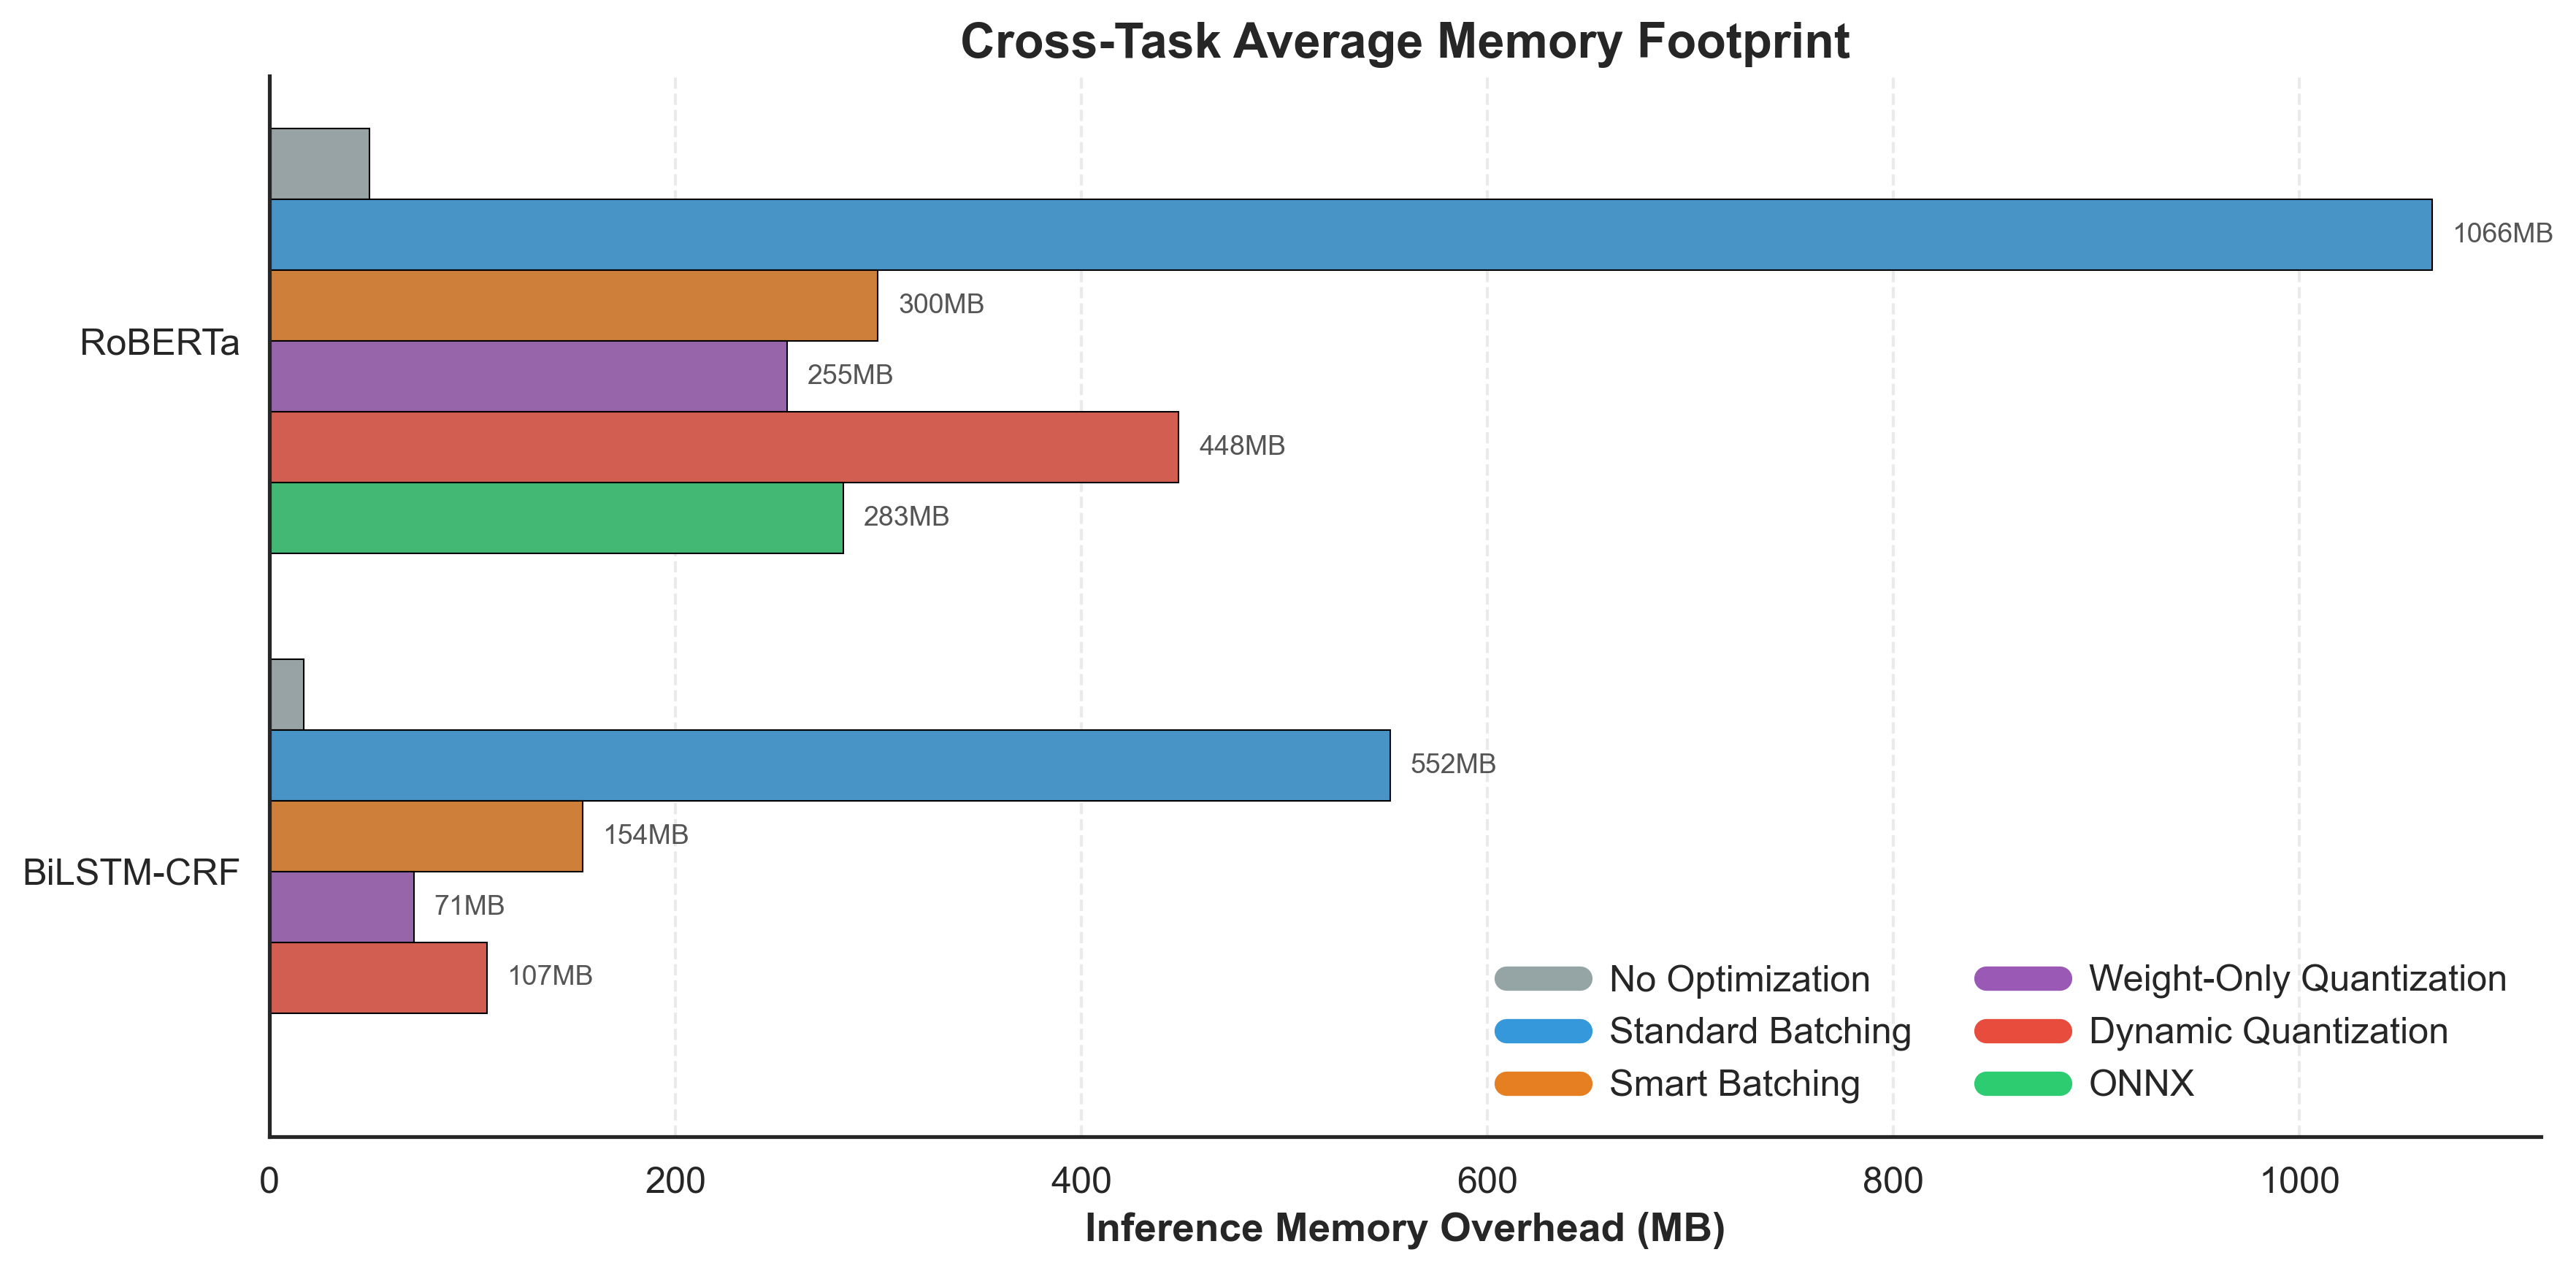

In [11]:
# --- Styling ---
sns.set_theme(style="white", font_scale=1.1)
plt.rcParams["font.family"] = "sans-serif"

# Shared color palette from previous plots
opt_colors = {
    "No Optimization": "#95a5a6",
    "Standard Batching": "#3498db",
    "Smart Batching": "#e67e22",
    "Dynamic Quantization": "#e74c3c",
    "Weight-Only Quantization": "#9b59b6",
    "ONNX": "#2ecc71",
}

# Prepare data inline
target_opts = [
    "No Optimization",
    "Standard Batching",
    "Smart Batching",
    "Weight-Only Quantization",
    "Dynamic Quantization",
    "ONNX",
]
plot_df = cross_task_results[
    cross_task_results["Optimization"].isin(target_opts)
].copy()

# Apply architecture mapping
plot_df["Architecture"] = plot_df["name"].apply(get_architecture)

# Filter to only RoBERTa and BiLSTM-CRF for comparison
arch_order = ["RoBERTa", "BiLSTM-CRF"]
plot_df = plot_df[plot_df["Architecture"].isin(arch_order)].copy()

plot_df["Architecture"] = pd.Categorical(
    plot_df["Architecture"], categories=arch_order, ordered=True
)
plot_df["Optimization"] = pd.Categorical(
    plot_df["Optimization"], categories=target_opts, ordered=True
)
data = plot_df.sort_values(["Architecture", "Optimization"], ascending=[True, True])

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

# Create the grouped horizontal bar chart
sns.barplot(
    data=data,
    y="Architecture",
    x="inference_memory_delta_mb",
    hue="Optimization",
    palette=opt_colors,
    ax=ax,
    edgecolor="black",
    linewidth=0.5,
    errorbar=None,  # Remove error bars (IQR)
)

# Add memory labels to bars, excluding small ones
for p in ax.patches:
    width = p.get_width()
    if width < 0:
        width = 0  # Handle negative delta anomalies

    # Only label bars with significant memory footprint (>50MB)
    if width > 50:
        ax.text(
            width + 10,
            p.get_y() + p.get_height() / 2,
            f"{width:.0f}MB",
            va="center",
            fontsize=9,
            color="#555",
        )

# Styling
ax.set_title(
    "Cross-Task Average Memory Footprint",
    loc="center",
    fontweight="bold",
    fontsize=16,
)
ax.set_xlabel("Inference Memory Overhead (MB)", fontweight="bold")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)


handles, labels = ax.get_legend_handles_labels()

# Create circular handles using Line2D with circular markers
circular_handles = [
    Line2D([0], [0], color=opt_colors[label], lw=8, label=label)
    for label in labels
]

ax.legend(
    handles=circular_handles,
    loc="lower right",
    ncol=2,
    frameon=False,
)

plt.tight_layout()